# Загрузка библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import ast
import time
import platform

from datetime import datetime
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

import lightgbm as lgb
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier, Pool

In [187]:
plt.rcParams['figure.figsize'] = (8, 5)  # 800x500 px
plt.rcParams['figure.dpi'] = 100

# Отключаем автоматическое масштабирование в Jupyter
%config InlineBackend.figure_format = 'retina'  # или 'png'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

## Вспомогательные функции

In [188]:
def log(msg):
    """Печать с timestamp"""
    print(f"[{datetime.now():%H:%M:%S}] {msg}")

In [189]:
def format_params(params, keys=None):
    """
    Форматирует словарь параметров в читаемый вид.
    
    Args:
        params: словарь параметров
        keys: список ключей для сохранения (если None — все)
    """
    if keys is not None:
        params = {k: v for k, v in params.items() if k in keys}
    
    return "\n".join([f"{k} = {v}" for k, v in params.items()])

In [190]:
def fmt(num):
    if num >= 1e9: return f"{num/1e9:.2f}B"
    elif num >= 1e6: return f"{num/1e6:.2f}M"
    elif num >= 1e3: return f"{num/1e3:.2f}K"
    return f"{num:.2f}"

In [ ]:
def log_experiment(model_name, params, k_fold, feature_importance_split, feature_importance_gain, features_info="", log_file='experiments_log_v2.csv'):
    """
    Сохраняет результаты эксперимента в CSV файл
    """
    log_file = Path(log_file)
    
    result = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'Kaggle Score': '',
        'model': model_name,
        'K-Fold': k_fold,
        'feature_importance_split': feature_importance_split,
        'feature_importance_gain': feature_importance_gain,
        'params': str(params),
        'features': features_info,
        'description': '',
        'os_full': platform.platform() 
    }
    
    if not log_file.exists():
        log_file.touch()
        pd.DataFrame(columns=result.keys()).to_csv(log_file, index=False)

    df_log = pd.read_csv(log_file)
    df_log = pd.concat([df_log, pd.DataFrame([result])], ignore_index=True)
    
    df_log.to_csv(log_file, index=False)
    
    print(f"Результат сохранён в {log_file}")
    print(df_log.sort_values('timestamp', ascending=False).to_string(index=False))
    
    return df_log

In [192]:
def visualize_experiments(log_file='experiments_log_v2.csv'):
    """
    Визуализирует все эксперименты из CSV файла.
    """
    try:
        df = pd.read_csv(log_file)
    except FileNotFoundError:
        print(f"Файл '{log_file}' не найден!")
        return None
    
    if len(df) == 0:
        print("Файл пустой, нет экспериментов для визуализации.")
        return df
    
    # Парсим timestamp и параметры
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['exp_num'] = range(1, len(df) + 1)
    
    def parse_params(p):
        try:
            return ast.literal_eval(p) if pd.notna(p) else {}
        except:
            return {}
    
    df['params_dict'] = df['params'].fillna('').apply(parse_params)
    df['depth'] = df['params_dict'].apply(lambda x: x.get('depth'))
    df['learning_rate'] = df['params_dict'].apply(lambda x: x.get('learning_rate'))
    df['iterations'] = df['params_dict'].apply(lambda x: x.get('iterations'))
    df['l2_leaf_reg'] = df['params_dict'].apply(lambda x: x.get('l2_leaf_reg'))
    
    print(f"Загружено экспериментов: {len(df)}")
    if 'val_bal_acc' in df.columns:
        best_idx = df['val_bal_acc'].idxmax()
        print(f"Лучший val_bal_acc: {df.loc[best_idx, 'val_bal_acc']:.4f} (Эксперимент #{best_idx + 1})")
    print("=" * 70)
    
    # ГРАФИК: ПРОГРЕСС ВО ВРЕМЕНИ
    if 'train_bal_acc' in df.columns and 'val_bal_acc' in df.columns:
        fig, ax = plt.subplots()
        
        ax.plot(df['exp_num'], df['train_bal_acc'], 'o-', label='Train BalAcc', color='skyblue', linewidth=2.5, markersize=8)
        ax.plot(df['exp_num'], df['val_bal_acc'], 's-', label='Val BalAcc', color='coral', linewidth=2.5, markersize=8)
        
        # Отмечаем лучший результат
        best = df.loc[best_idx]
        ax.scatter(best['exp_num'], best['val_bal_acc'], s=300, color='red', marker='*', zorder=5, label=f'Best (#{int(best["exp_num"])})')
        ax.annotate(f"Val: {best['val_bal_acc']:.4f}", 
                    xy=(best['exp_num'], best['val_bal_acc']),
                    xytext=(20, 10), textcoords='offset points',
                    fontsize=11, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red'))
        
        ax.set_xlabel('Номер эксперимента', fontsize=13)
        ax.set_ylabel('Balanced Accuracy', fontsize=13)
        ax.set_title('Прогресс экспериментов во времени', fontsize=15, fontweight='bold')
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(df['exp_num'])
        plt.tight_layout()
        plt.show()
    
    # ГРАФИК: АНАЛИЗ ПЕРЕОБУЧЕНИЯ (GAP)
    if 'gap' in df.columns:
        fig, ax = plt.subplots()
        
        colors = ['green' if g < 0.01 else 'orange' if g < 0.03 else 'red' for g in df['gap']]
        bars = ax.bar(df['exp_num'], df['gap'], color=colors, alpha=0.7, edgecolor='black')
        
        ax.axhline(y=0.01, color='green', linestyle='--', alpha=0.7, label='Отлично (< 1%)')
        ax.axhline(y=0.03, color='orange', linestyle='--', alpha=0.7, label='Нормально (< 3%)')
        ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Переобучение (> 5%)')
        
        for bar, gap in zip(bars, df['gap']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(df['gap']) * 0.02,
                    f"{gap:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Номер эксперимента', fontsize=13)
        ax.set_ylabel('Gap (Train - Val)', fontsize=13)
        ax.set_title('Анализ переобучения (Gap)', fontsize=15, fontweight='bold')
        ax.set_xticks(df['exp_num'])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
    
    # СВОДНАЯ ТАБЛИЦА
    cols_to_show = ['exp_num', 'model', 'depth', 'learning_rate', 'iterations', 'train_bal_acc', 'val_bal_acc', 'gap', 'features']
    cols_to_show = [c for c in cols_to_show if c in df.columns]
    
    summary = df[cols_to_show].copy()
    summary.columns = ['#', 'Model', 'Depth', 'LR', 'Iters', 'Train', 'Val', 'Gap', 'Features']
    
    print("\nСводная таблица экспериментов:")
    
    if 'val_bal_acc' in df.columns:
        # Форматируем числовые колонки для красивого вывода
        display_summary = summary.copy()
        for col in ['Train', 'Val', 'Gap']:
            if col in display_summary.columns:
                display_summary[col] = display_summary[col].apply(
                    lambda x: f"{x:.4f}" if pd.notna(x) else ""
                )
        
        # Добавляем маркер лучшего эксперимента
        best_exp_num = df.loc[best_idx, 'exp_num']
        display_summary['Best'] = display_summary['#'].apply(
            lambda x: "⭐" if x == best_exp_num else ""
        )
        
        # Переупорядочиваем колонки
        cols_order = ['Best', '#', 'Model', 'Depth', 'LR', 'Iters', 'Train', 'Val', 'Gap', 'Features']
        display_summary = display_summary[[c for c in cols_order if c in display_summary.columns]]
        
        # Пытаемся использовать красивый стиль, если jinja2 доступен
        try:
            def highlight_row(row):
                if row['#'] == best_exp_num:
                    return ['background-color: gold; font-weight: bold'] * len(row)
                return [''] * len(row)
            
            styled = display_summary.style.apply(highlight_row, axis=1)
            display(styled)
        except (ImportError, AttributeError):
            # Если jinja2 не установлен, показываем обычную таблицу
            print("(Установите 'pip install jinja2' для красивого форматирования)")
            display(display_summary)
    
    return df

In [193]:
def analyze_feature_importance(model, X, top_n=75, importance_type='split'):
    """
    Анализирует важность признаков модели LightGBM.
    
    Args:
        model: обученная модель LightGBM
        X: данные (DataFrame) для получения названий признаков
        top_n: количество топ-признаков для отображения
        plot: строить ли график
        figsize: размер графика
    
    Returns:
        str: отформатированная строка с важностью признаков для логирования
    """
    # Для LightGBM можно получить разные типы важности
    if importance_type == 'gain':
        booster = model.booster_
        importances = booster.feature_importance(importance_type='gain')
    else:
        importances = model.feature_importances_

    feature_names = X.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"Топ-{top_n} важных признаков:")
    print(fi_df.head(top_n).to_string(index=False))
    
    if importance_type == 'gain':
        total = fi_df['Importance'].sum()
        top_features_for_log = {}
        for _, row in fi_df.head(top_n).iterrows():
            pct = row['Importance'] / total * 100
            top_features_for_log[row['Feature']] = f"{fmt(row['Importance'])} ({pct:.1f}%)"
    else:
        top_features_for_log = fi_df.head(top_n).set_index('Feature')['Importance'].to_dict()
    
    return fi_df, top_features_for_log

In [194]:
def plot_feature_importance(fi_df, top_n=75, figsize=(10, 15), importance_type='split'):
    """Строит график важности признаков."""
    plt.figure(figsize=figsize)
    plt.barh(fi_df['Feature'][:top_n][::-1], fi_df['Importance'][:top_n][::-1])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance (LightGBM, {importance_type})')
    plt.tight_layout()
    plt.show()

# Загрузка данных

In [195]:
ID_COL = 'id'
TARGET_COL = 'class'
NUMERIC_COLS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
CATEGORICAL_COLS = ['spectral_type', 'galaxy_population']

In [196]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [197]:
display(train_df.shape)
display(test_df.shape)

(577347, 12)

(247435, 11)

In [198]:
display(train_df.head(5))
display(test_df.head(5))

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [199]:
display(train_df.info())
display(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  str    
 10  galaxy_population  247435 non-null  str    
dtypes: float64(8), int64(1), str(2)
memory usage: 20.8 MB


None

In [200]:
display(train_df.describe())
display(test_df.describe())

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


,id,alpha,delta,u,g,r,i,z,redshift
count,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000,247435.000000
mean,701064.000000,181.360629,21.853898,22.442070,21.009837,19.965651,19.381860,19.043151,0.724780
std,71428.476266,96.213374,18.931367,2.019044,1.798633,1.650949,1.581880,1.587103,0.810582
min,577347.000000,0.010959,-17.959259,13.902664,13.374549,10.390731,10.034180,10.632025,-0.009968
25%,639205.500000,132.023953,2.527822,20.978208,19.866076,18.831805,18.314240,17.976477,0.183117
50%,701064.000000,188.559428,21.452023,22.569616,21.469175,20.431512,19.632235,19.196316,0.498598
75%,762922.500000,231.690068,37.061924,23.869689,22.294539,21.165467,20.618391,20.167750,0.882659
max,824781.000000,359.999724,79.170436,27.835633,27.173411,25.291984,24.567823,25.700336,7.007179


# Разведочный анализ данных

In [201]:
for column in CATEGORICAL_COLS:
    display(train_df[column].value_counts())

display(train_df[TARGET_COL].value_counts())

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

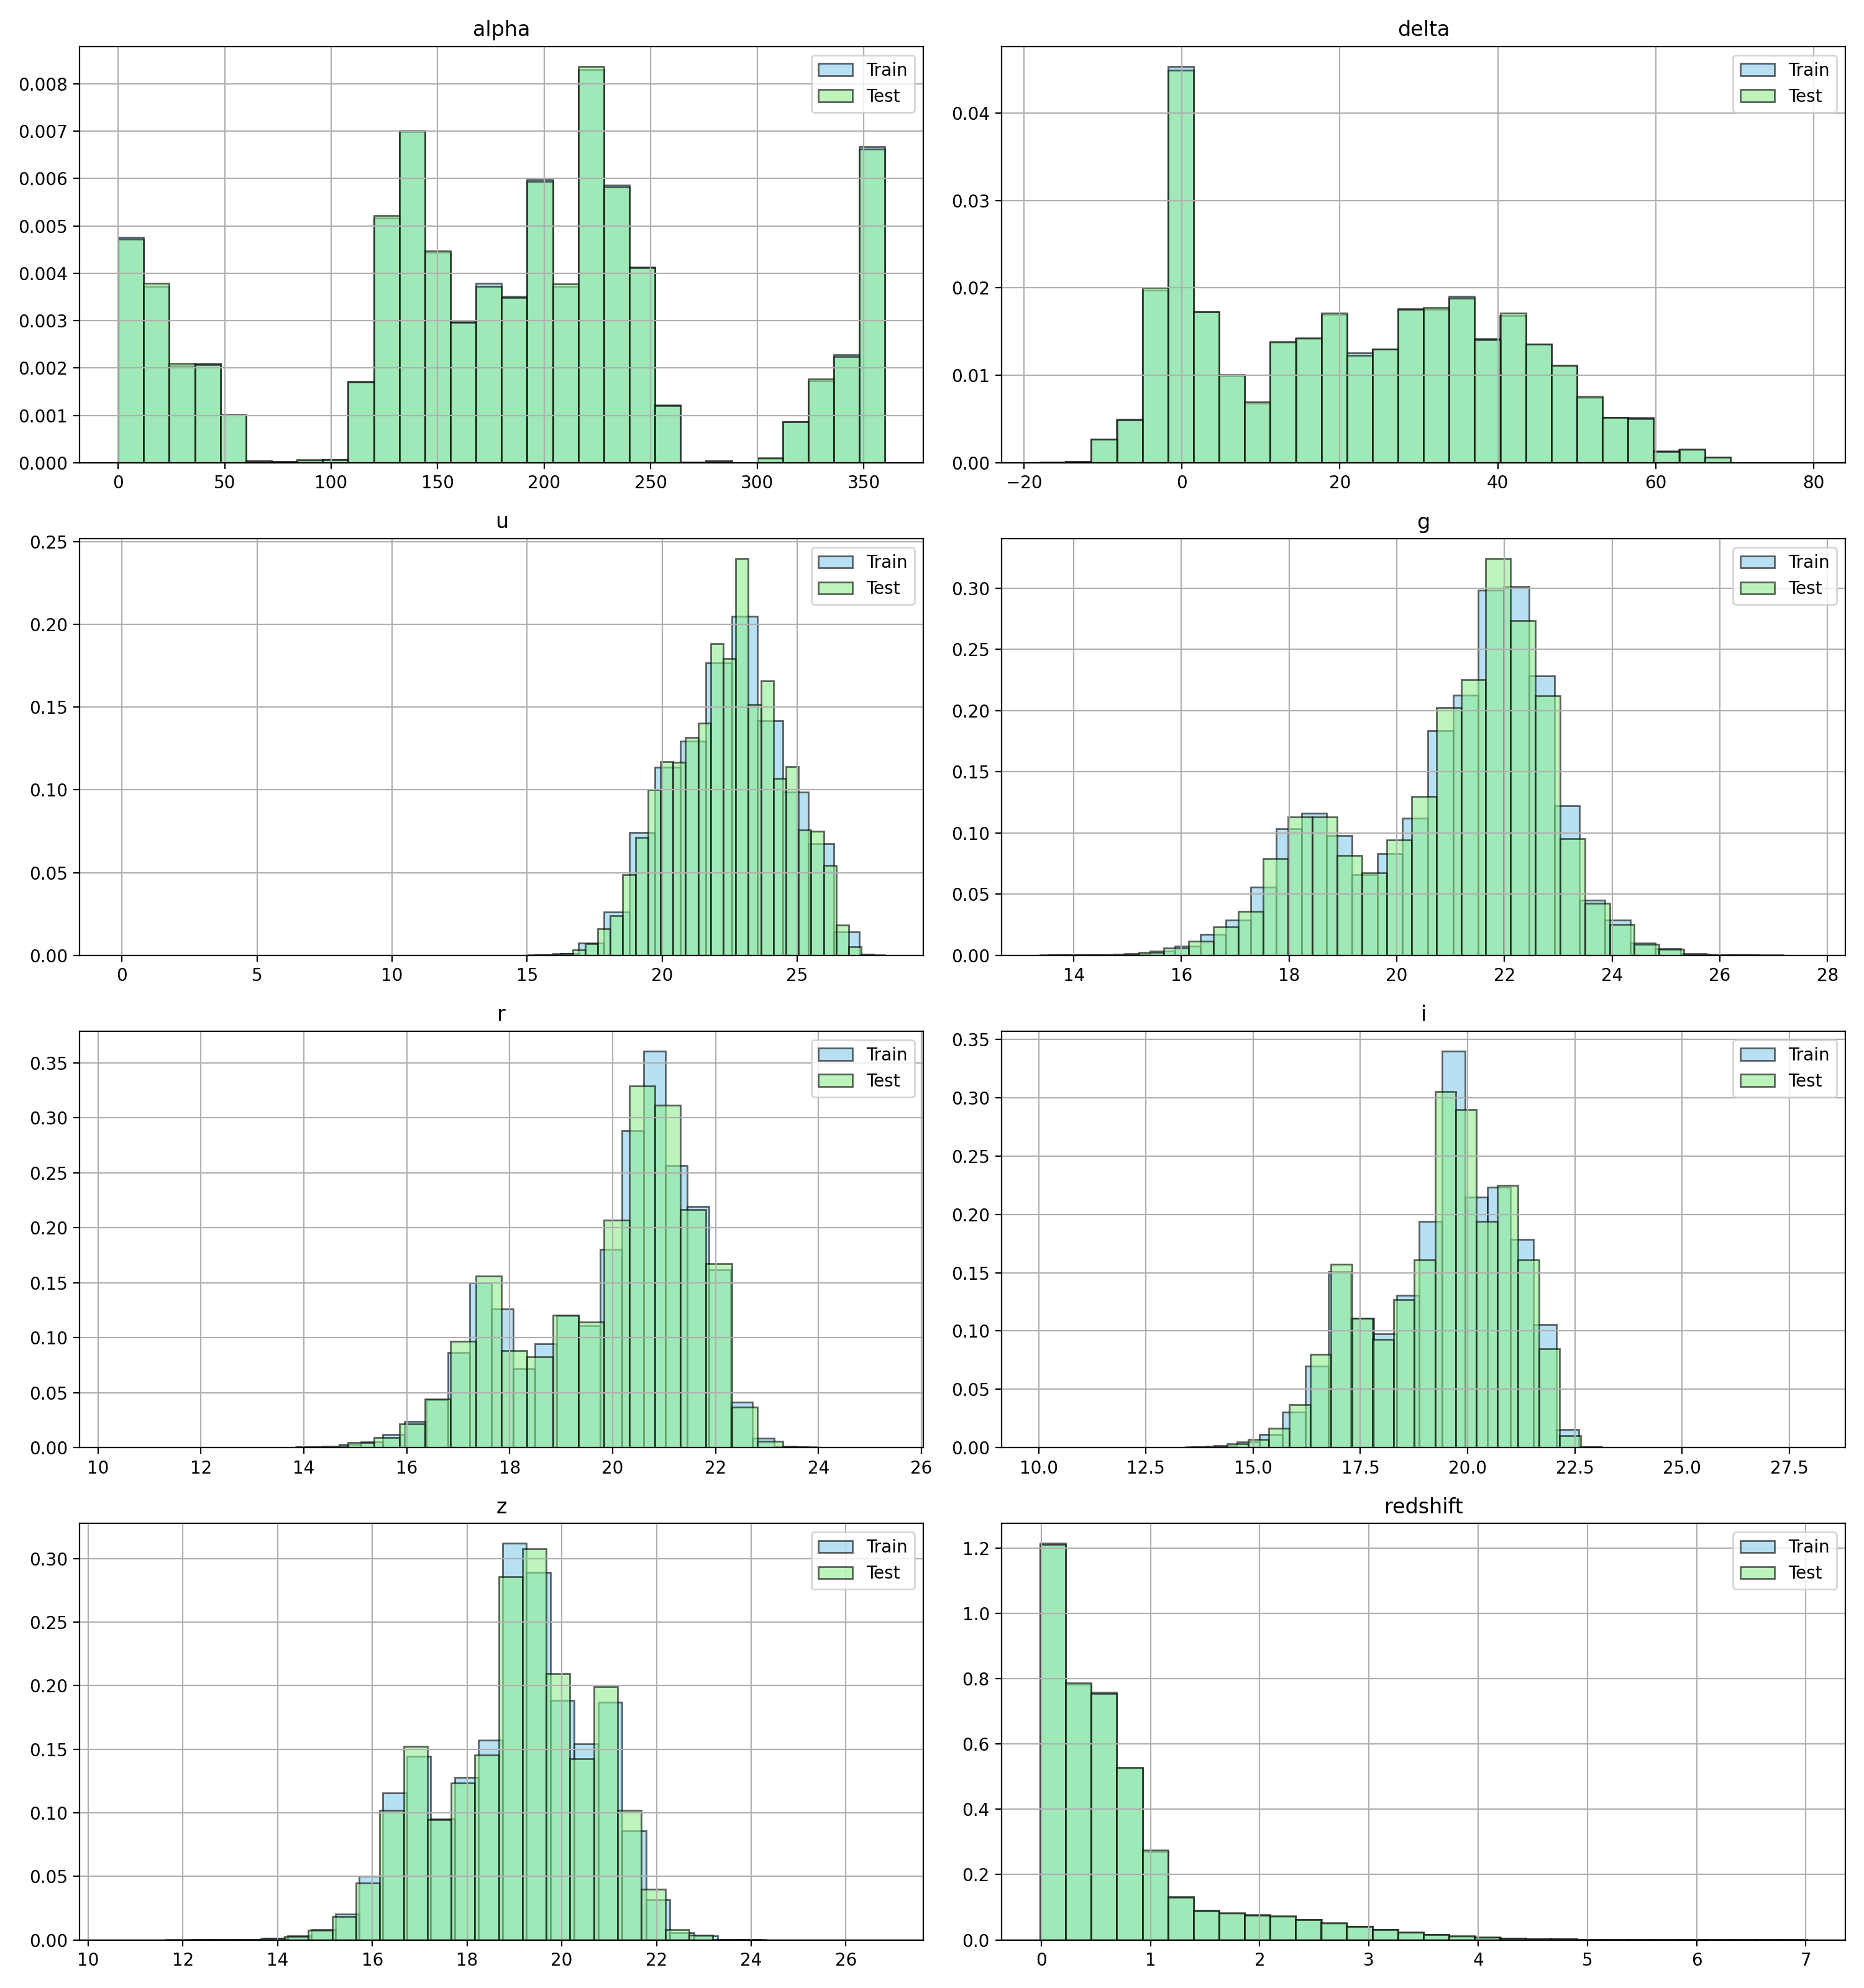

In [202]:
# 1. Оставляем только числовые колонки
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
cols_to_plot = [col for col in numeric_cols if col != 'id']

# 2. Настраиваем сетку для графиков
n_cols = len(cols_to_plot)
ncols = 2  # Количество столбцов в сетке
nrows = int(np.ceil(n_cols / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

# 3. Рисуем гистограммы
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # density=True нормирует гистограмму так, чтобы площадь = 1
    # Теперь по оси Y будет не "количество", а "плотность вероятности"
    train_df[col].hist(ax=ax, bins=30, alpha=0.6, label='Train', color='skyblue', edgecolor='black', density=True)
    test_df[col].hist(ax=ax, bins=30, alpha=0.6, label='Test', color='lightgreen', edgecolor='black', density=True)
    
    ax.set_title(col)
    ax.legend()

# 4. Удаляем пустые графики, если их количество не кратно ncols
for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

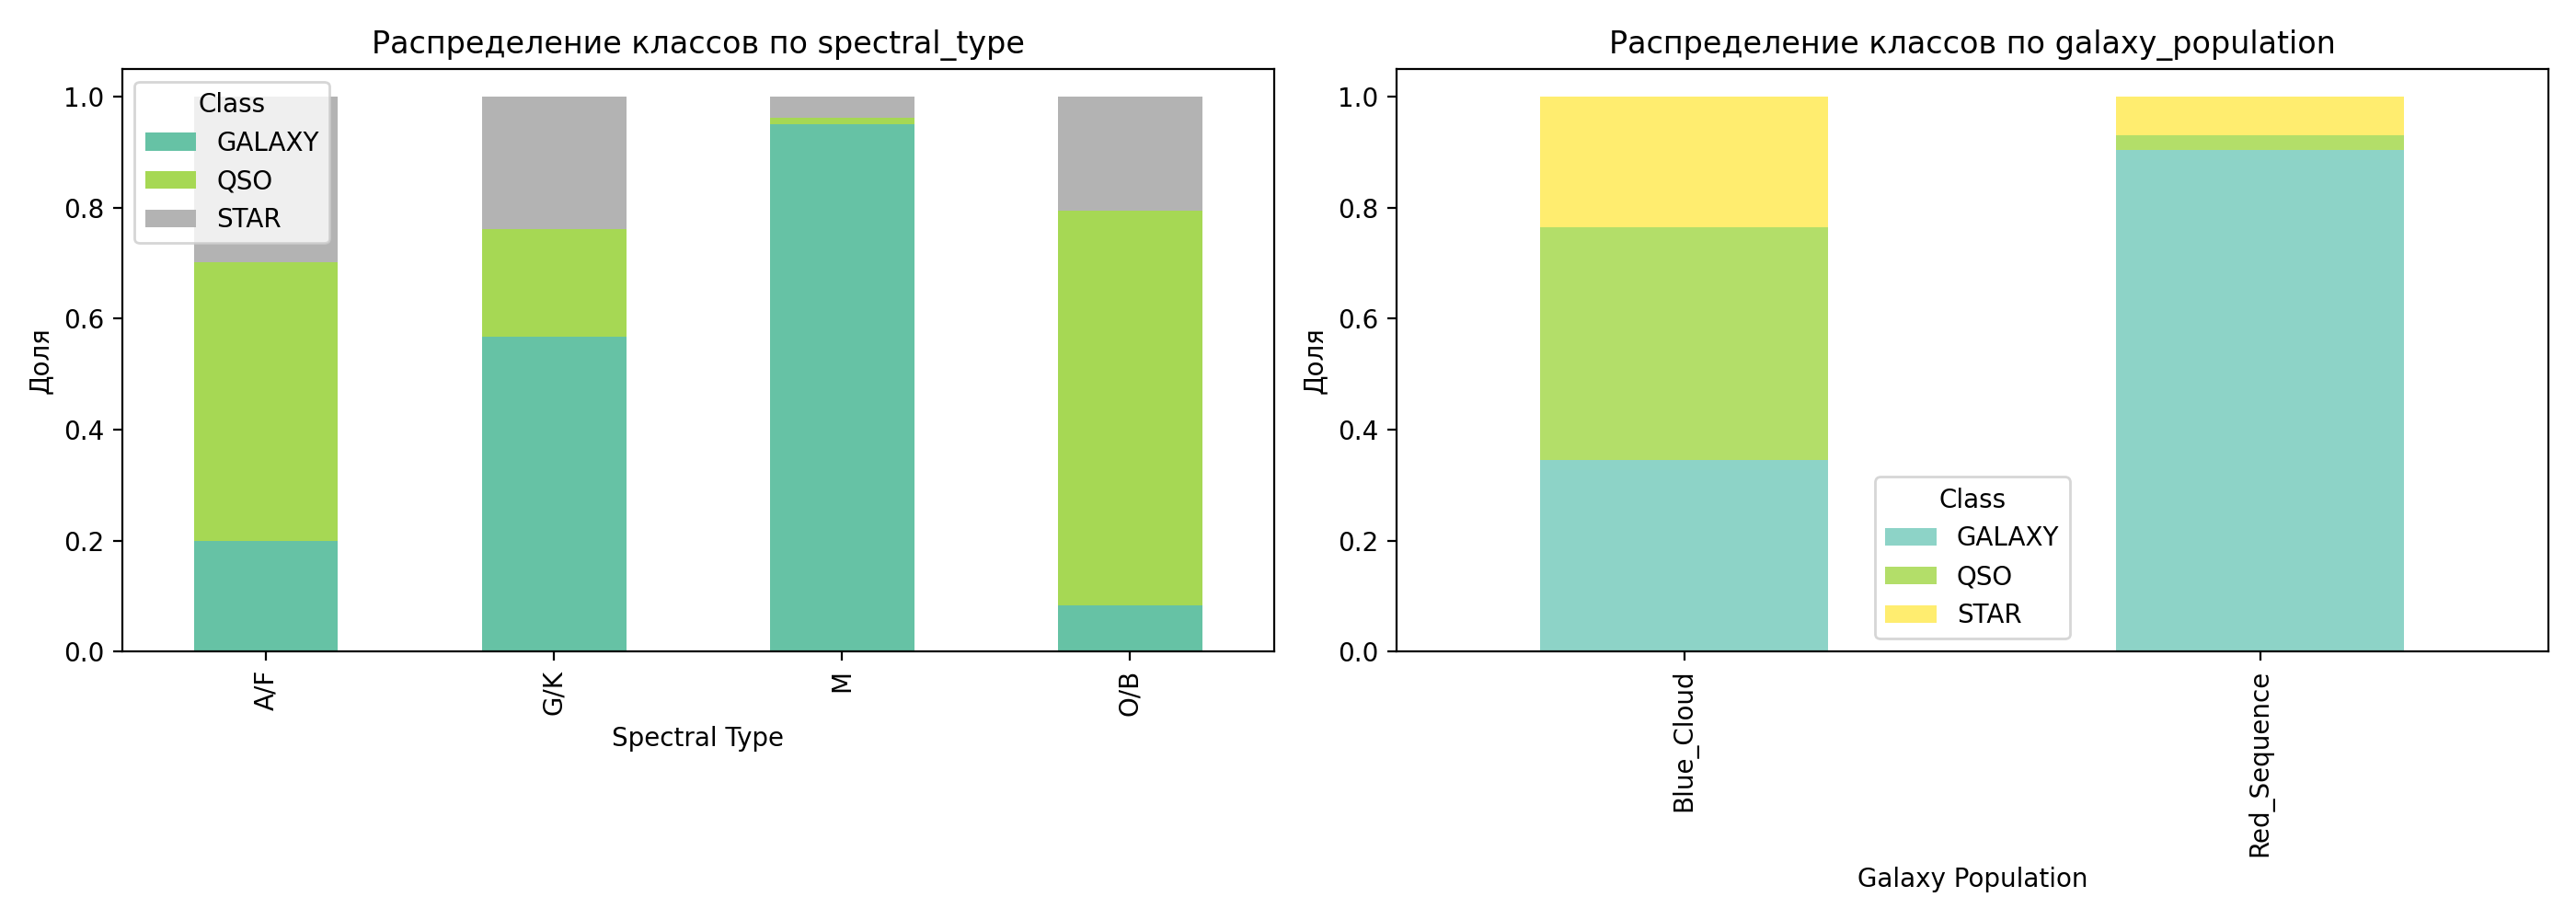

In [203]:
# Считаем долю каждого класса внутри категории
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: spectral_type vs class
pd.crosstab(train_df['spectral_type'], train_df['class'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], colormap='Set2'
)
axes[0].set_title('Распределение классов по spectral_type')
axes[0].set_ylabel('Доля')
axes[0].set_xlabel('Spectral Type')
axes[0].legend(title='Class')

# График 2: galaxy_population vs class
pd.crosstab(train_df['galaxy_population'], train_df['class'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], colormap='Set3'
)
axes[1].set_title('Распределение классов по galaxy_population')
axes[1].set_ylabel('Доля')
axes[1].set_xlabel('Galaxy Population')
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

## Корреляция признаков

### Heatmap корреляции признаков

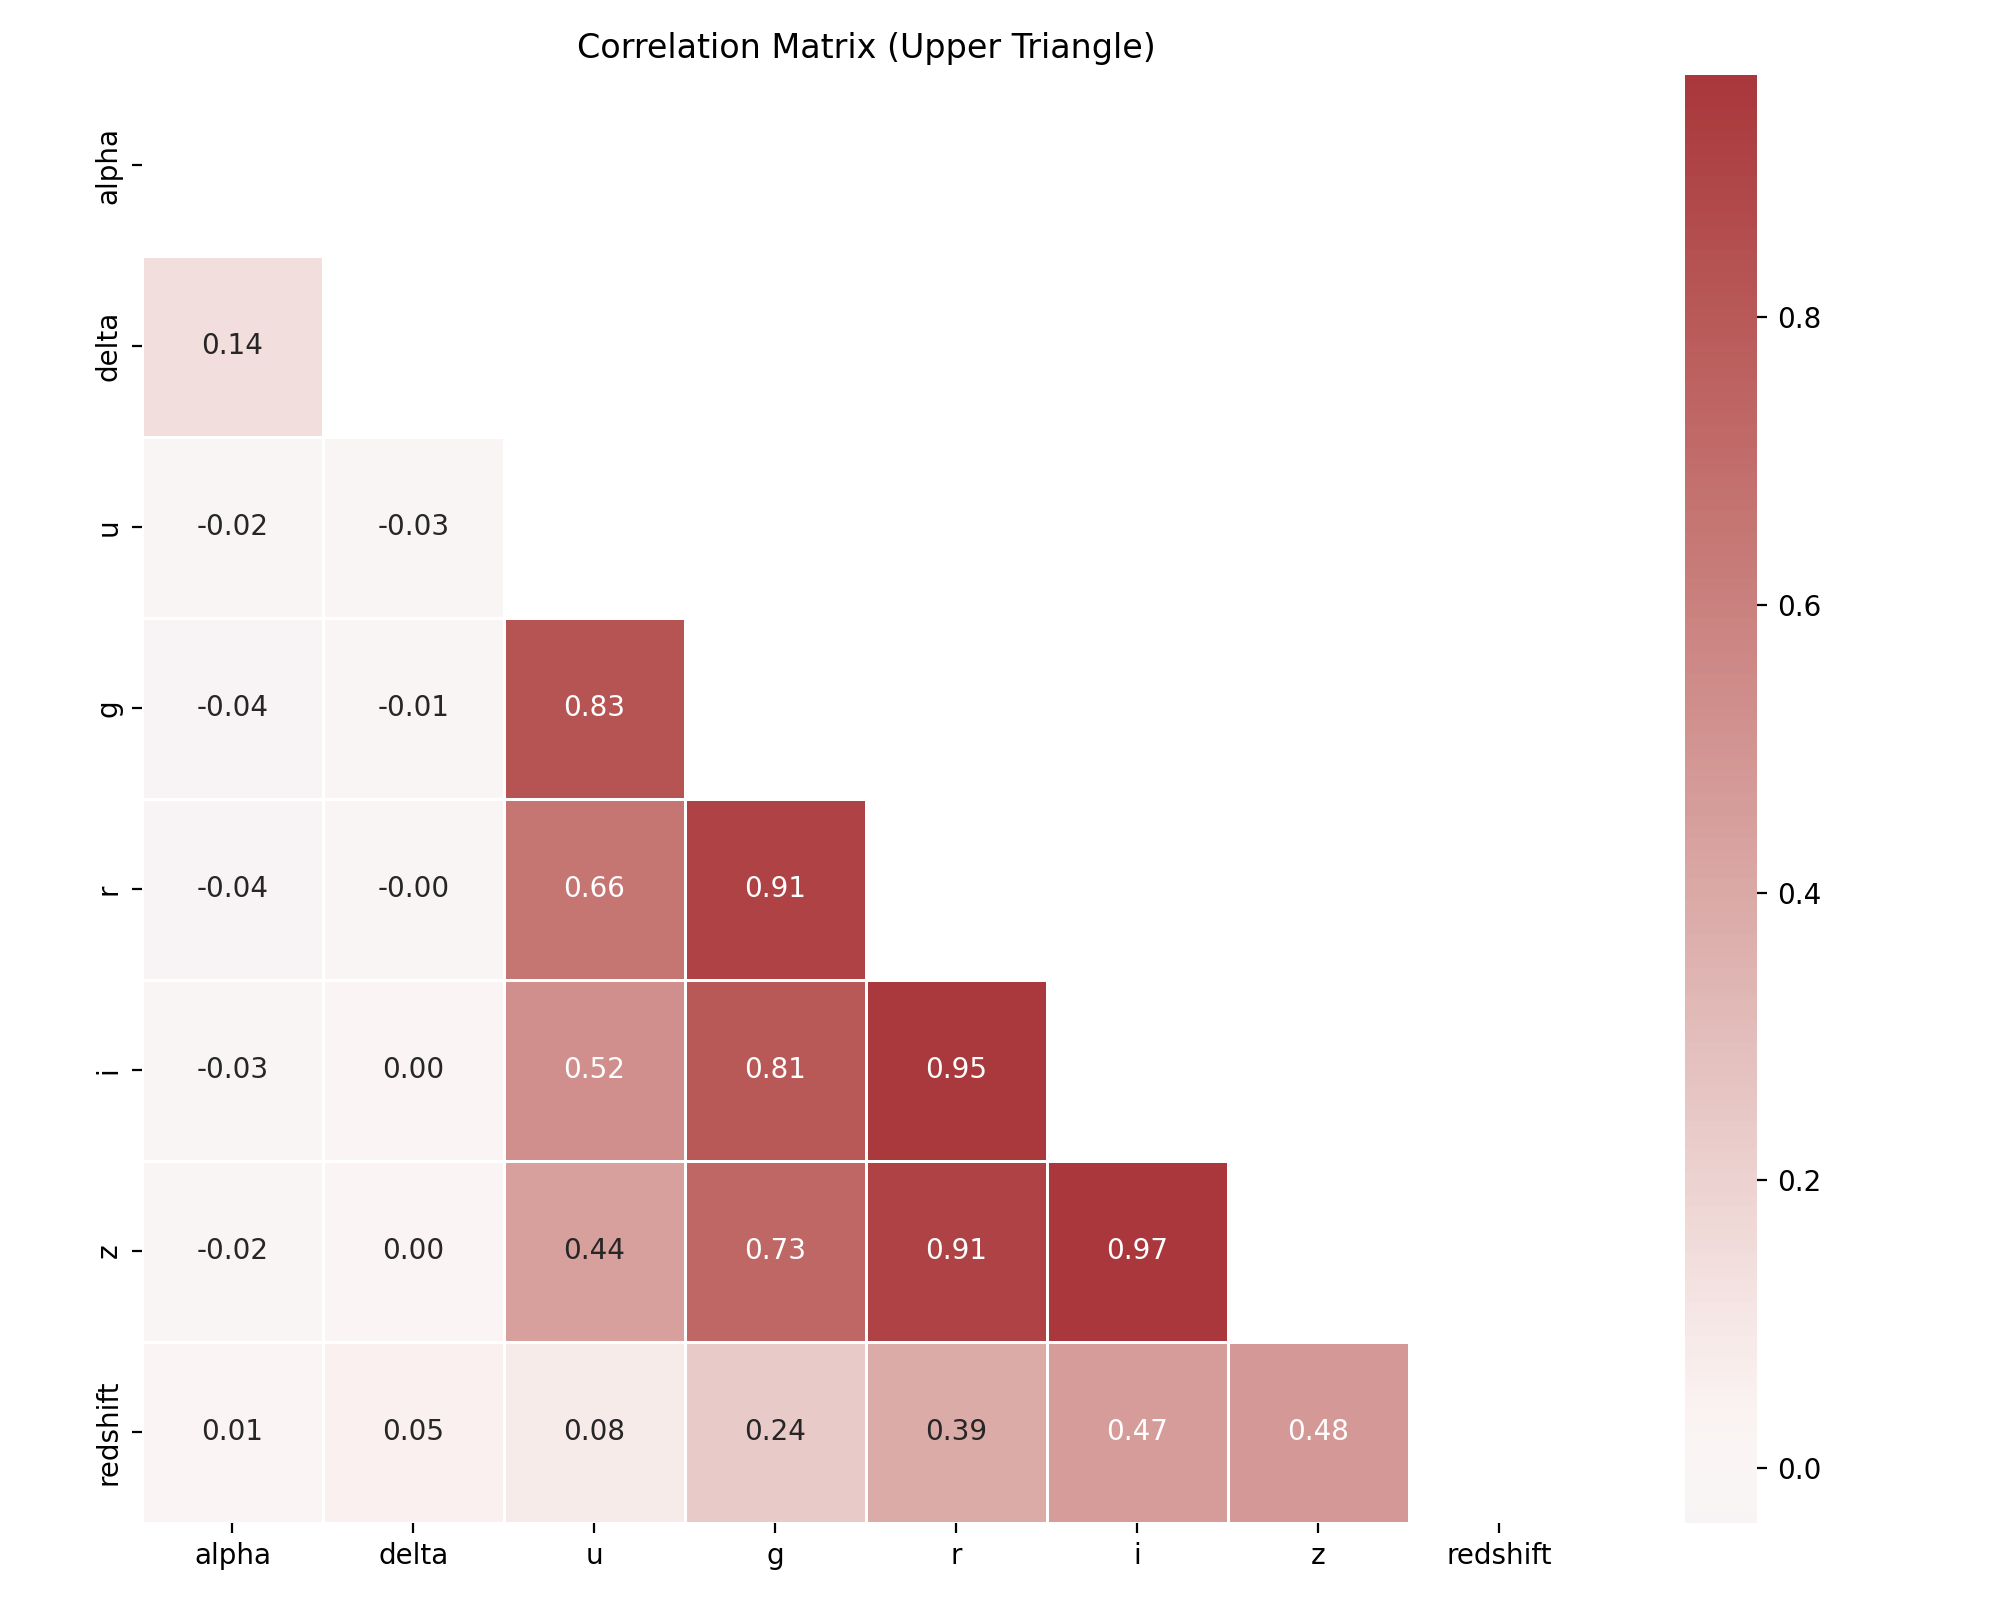

In [204]:
corr_matrix = train_df[NUMERIC_COLS].corr()
# display(corr_matrix)

# Показывает только верхнюю треугольную матрицу (без дублирования)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='vlag', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix (Upper Triangle)')
plt.tight_layout()
plt.show()

### Корреляция с целевой переменной

In [205]:
le = LabelEncoder()
y_encoded = le.fit_transform(train_df['class'])

correlations = []
for col in NUMERIC_COLS:
    corr = train_df[col].corr(pd.Series(y_encoded))
    correlations.append((col, corr))

# Сортируем по абсолютному значению
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("Корреляция признаков с target:")
for col, corr in correlations:
    print(f"{col:15} : {corr:.4f}")

Корреляция признаков с target:
u               : -0.3857
g               : -0.2850
z               : 0.1905
i               : 0.1076
redshift        : 0.0778
r               : -0.0498
alpha           : 0.0336
delta           : 0.0174


# Feature Engineering

In [206]:
def equatorial_to_galactic(alpha_deg, delta_deg):
    """Перевод из экваториальных в галактические координаты (J2000)"""
    alpha = np.radians(alpha_deg)
    delta = np.radians(delta_deg)
    
    # Координаты северного галактического полюса
    alpha_gp = np.radians(192.85948)
    delta_gp = np.radians(27.12825)
    l_ncp = np.radians(122.93192)
    
    # Формулы преобразования
    sin_b = np.sin(delta_gp) * np.sin(delta) + np.cos(delta_gp) * np.cos(delta) * np.cos(alpha - alpha_gp)
    b = np.arcsin(sin_b)
    
    y = np.cos(delta) * np.sin(alpha - alpha_gp)
    x = np.cos(delta_gp) * np.sin(delta) - np.sin(delta_gp) * np.cos(delta) * np.cos(alpha - alpha_gp)
    l = np.arctan2(y, x) + l_ncp
    
    # Нормализация l в [0, 360]
    l = np.degrees(l) % 360
    b = np.degrees(b)
    
    return l, b

# Создаём галактические координаты
train_df['galactic_l'], train_df['galactic_b'] = equatorial_to_galactic(
    train_df['alpha'], train_df['delta']
)
test_df['galactic_l'], test_df['galactic_b'] = equatorial_to_galactic(
    test_df['alpha'], test_df['delta']
)

# Sin/cos для периодичности (как с alpha)
train_df['sin_gal_l'] = np.sin(np.radians(train_df['galactic_l']))
train_df['cos_gal_l'] = np.cos(np.radians(train_df['galactic_l']))
train_df['sin_gal_b'] = np.sin(np.radians(train_df['galactic_b']))
train_df['cos_gal_b'] = np.cos(np.radians(train_df['galactic_b']))

test_df['sin_gal_l'] = np.sin(np.radians(test_df['galactic_l']))
test_df['cos_gal_l'] = np.cos(np.radians(test_df['galactic_l']))
test_df['sin_gal_b'] = np.sin(np.radians(test_df['galactic_b']))
test_df['cos_gal_b'] = np.cos(np.radians(test_df['galactic_b']))

# Удаляем сами galactic_l и galactic_b (sin/cos лучше для деревьев)
train_df = train_df.drop(columns=['galactic_l', 'galactic_b'])
test_df = test_df.drop(columns=['galactic_l', 'galactic_b'])

alpha_rad = np.radians(train_df['alpha'])
train_df['sin_alpha'] = np.sin(alpha_rad)
train_df['cos_alpha'] = np.cos(alpha_rad)

alpha_rad_t = np.radians(test_df['alpha'])
test_df['sin_alpha'] = np.sin(alpha_rad_t)
test_df['cos_alpha'] = np.cos(alpha_rad_t)

train_df = train_df.drop(columns=['alpha'])
test_df = test_df.drop(columns=['alpha'])

train_df['sin_delta'] = np.sin(np.radians(train_df['delta']))
test_df['sin_delta'] = np.sin(np.radians(test_df['delta']))

train_df['cos_delta'] = np.cos(np.radians(train_df['delta']))
test_df['cos_delta'] = np.cos(np.radians(test_df['delta']))

train_df = train_df.drop(columns=['delta'])
test_df = test_df.drop(columns=['delta'])

# Упрощённый расчёт светимости (Luminosity distance) для плоской Вселенной
# c = 299792 km/s, H0 = 70 km/s/Mpc, q0 = -0.55
def get_absolute_magnitude(m_apparent, z):
    # Светимость в Мпк
    d_L = (299792.458 / 70) * z * (1 + (1 - (-0.55)) / 2 * z)
    # Модуль расстояния
    mu = 5 * np.log10(d_L * 1e6) - 5
    # Абсолютная величина
    return m_apparent - mu

# Считаем для r-фильтра (наиболее стабильный)
train_df['abs_mag_r'] = get_absolute_magnitude(train_df['r'], train_df['redshift'])
test_df['abs_mag_r'] = get_absolute_magnitude(test_df['r'], test_df['redshift'])

train_df['curvature_ugr'] = (train_df['u'] - train_df['g']) - (train_df['g'] - train_df['r'])
test_df['curvature_ugr'] = (test_df['u'] - test_df['g']) - (test_df['g'] - test_df['r'])

/Users/dmitriytonkusin/ML/Predicting Stellar Class/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Baseline. LightGBM

In [207]:
key_params = [
    'n_estimators', 'learning_rate', 'max_depth', 
    'num_leaves', 'subsample', 'colsample_bytree',
    'min_child_samples', 'class_weight'
]

In [208]:
for col in CATEGORICAL_COLS:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

# Подготовка данных
X_train = train_df.drop(columns=[ID_COL, TARGET_COL])
y_train = train_df[TARGET_COL]
X_test = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL]

In [209]:
MODEL_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.1,
    'max_depth': 8,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1,
    #'device': 'gpu'
}

In [210]:
FINAL_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'max_depth': 10,
    'num_leaves': 63,
    'min_child_samples': 10,
    'min_child_weight': 0.001,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

In [211]:
MAX_COMPLEX_PARAMS = {
    'n_estimators': 10000,
    'learning_rate': 0.005,
    'max_depth': 15,
    'num_leaves': 255,
    'min_child_samples': 5,
    'min_child_weight': 0.001,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

In [212]:
# 5-FOLD КРОСС-ВАЛИДАЦИЯ
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_scores = []
oof_lgb = np.zeros((len(X_train), 3))  # OOF для blend
lgb_classes = None

log(f"Начинаем {n_splits}-fold кросс-валидацию...")
cv_start = time.perf_counter()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    log(f"Fold {fold}/{n_splits}...")
    
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model_fold = LGBMClassifier(**FINAL_PARAMS)
    
    # Early stopping на валидационной выборке
    model_fold.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        callbacks=[
            lgb.log_evaluation(period=500)  # Лог каждые 500 деревьев
        ]
    )
    
    # Out-of-fold предсказания (вероятности)
    lgb_classes = model_fold.classes_
    oof_lgb[val_idx] = model_fold.predict_proba(X_fold_val)
    
    # Оценка на валидации этого фолда
    fold_pred = model_fold.predict(X_fold_val)
    fold_score = balanced_accuracy_score(y_fold_val, fold_pred)
    fold_scores.append(fold_score)
    
    log(f"  Fold {fold} BalAcc: {fold_score:.4f}")

# Усреднённая метрика по всем фолдам
mean_cv_score = np.mean(fold_scores)
std_cv_score = np.std(fold_scores)

# OOF предсказания (классы)
oof_classes_lgb = lgb_classes[np.argmax(oof_lgb, axis=1)]
oof_score = balanced_accuracy_score(y_train, oof_classes_lgb)

cv_end = time.perf_counter()
cv_time = cv_end - cv_start

# Создаём словарь с результатами CV
cv_results = {
    'Mean BalAcc': f'{mean_cv_score:.4f} ± {std_cv_score:.4f}',
    'Min': f'{min(fold_scores):.4f}',
    'Max': f'{max(fold_scores):.4f}',
    'OOF BalAcc': f'{oof_score:.4f}',
    'Time (sec)': f'{cv_time:.1f}'
}

# ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ НА ВСЕХ ДАННЫХ
model_lgb_final = LGBMClassifier(**FINAL_PARAMS)

model_lgb_final.fit(
    X_train, y_train, 
    callbacks=[
        lgb.log_evaluation(period=500)
    ]
)

log("\nФинальная модель обучена на всех данных train")

proba_lgb_test = model_lgb_final.predict_proba(X_test)
predictions_lgb = model_lgb_final.predict(X_test)
predictions = predictions_lgb

log(f"Количество предсказаний: {len(predictions)}")
log(f"Распределение классов:")
log(pd.Series(predictions).value_counts())

fi_df_split, fi_split = analyze_feature_importance(model_lgb_final, X_train, importance_type='split')
fi_df_gain, fi_gain = analyze_feature_importance(model_lgb_final, X_train, importance_type='gain')

# plot_feature_importance(fi_df_split, importance_type='split')
# plot_feature_importance(fi_df_gain, importance_type='gain')

log_experiment(
    model_name='LightGBM',
    params=format_params(model_lgb_final.get_params(), keys=key_params),
    k_fold=format_params(cv_results),
    feature_importance_split=format_params(fi_split),
    feature_importance_gain=format_params(fi_gain),
    features_info='FINAL_PARAMS\nbase\n+ sin_alpha\n+ cos_alpha\n+ abs_mag_r\n+ curvature_ugr\n+ sin_delta\n+ cos_delta\n- alpha\n- delta'
)

[13:25:35] Начинаем 5-fold кросс-валидацию...
[13:25:35] Fold 1/5...
[500]	valid_0's multi_logloss: 0.108886
[1000]	valid_0's multi_logloss: 0.10167
[1500]	valid_0's multi_logloss: 0.0983146
[2000]	valid_0's multi_logloss: 0.09656
[13:26:56]   Fold 1 BalAcc: 0.9661
[13:26:56] Fold 2/5...
[500]	valid_0's multi_logloss: 0.110337
[1000]	valid_0's multi_logloss: 0.103472
[1500]	valid_0's multi_logloss: 0.100445
[2000]	valid_0's multi_logloss: 0.0987946
[13:28:18]   Fold 2 BalAcc: 0.9651
[13:28:18] Fold 3/5...
[500]	valid_0's multi_logloss: 0.114426
[1000]	valid_0's multi_logloss: 0.106946
[1500]	valid_0's multi_logloss: 0.103844
[2000]	valid_0's multi_logloss: 0.102309
[13:29:40]   Fold 3 BalAcc: 0.9648
[13:29:40] Fold 4/5...
[500]	valid_0's multi_logloss: 0.109553
[1000]	valid_0's multi_logloss: 0.102667
[1500]	valid_0's multi_logloss: 0.0992923
[2000]	valid_0's multi_logloss: 0.0977863
[13:31:03]   Fold 4 BalAcc: 0.9646
[13:31:03] Fold 5/5...
[500]	valid_0's multi_logloss: 0.111647
[1000

,timestamp,Kaggle Score,model,K-Fold,feature_importance_split,feature_importance_gain,params,features,description,os_full
0,2026-06-07 10:21:50,0.96328,LightGBM,Mean BalAcc = 0.9634 ± 0.0011\nMin = 0.9620\nM...,redshift = 6607\ndelta = 6522\nalpha = 6479\nu...,u = 5.51B (56.2%)\nredshift = 959.12M (9.8%)\n...,class_weight = balanced\ncolsample_bytree = 0....,base,Базовый набор признаков. Стабильный baseline. ...,MacOS
1,2026-06-07 10:28:59,0.96357,LightGBM,Mean BalAcc = 0.9621 ± 0.0001\nMin = 0.9619\nM...,alpha = 6604\nredshift = 6444\ndelta = 6407\nu...,i = 274.15M (23.9%)\ng = 184.21M (16.0%)\nreds...,class_weight = balanced\ncolsample_bytree = 0....,base\nredshift_log,Добавлен redshift_log. Дублирование с redshift...,MacOS
2,2026-06-07 10:40:55,0.96243,LightGBM,Mean BalAcc = 0.9640 ± 0.0008\nMin = 0.9631\nM...,redshift_log = 6733\nalpha = 6626\ndelta = 630...,delta = 7.38B (42.0%)\nredshift_log = 4.03B (2...,class_weight = balanced\ncolsample_bytree = 0....,base\nredshift_log (drop redshift),"Замена redshift на redshift_log. Kaggle упал, ...",MacOS
3,2026-06-07 10:55:16,0.96256,LightGBM,Mean BalAcc = 0.9628 ± 0.0015\nMin = 0.9607\nM...,redshift = 6499\ndelta = 6349\nalpha = 6247\nu...,r = 715.35M (21.7%)\ng = 652.76M (19.8%)\nreds...,class_weight = balanced\ncolsample_bytree = 0....,base\ncolor_gr,Добавлен color_gr. Оба K-Fold и Kaggle ухудшил...,MacOS
4,2026-06-07 11:02:49,0.96309,LightGBM,Mean BalAcc = 0.9634 ± 0.0012\nMin = 0.9618\nM...,redshift = 6788\ndelta = 6217\nu = 5230\nz = 4...,alpha = 544.66M (31.9%)\ncoord_dist = 401.56M ...,class_weight = balanced\ncolsample_bytree = 0....,base\ncoord_dist,Добавлен coord_dist. K-Fold не изменился (0.96...,MacOS
5,2026-06-07 11:13:59,0.95049,LightGBM,Mean BalAcc = 0.9495 ± 0.0002\nMin = 0.9493\nM...,redshift = 8060\nu = 7903\nz = 7371\ng = 7283\...,galaxy_population = 797.27M (52.5%)\nz = 423.2...,class_weight = balanced\ncolsample_bytree = 0....,base\ndrop alpha\ndrop delta,Удалены alpha и delta. Значительное падение: K...,MacOS
6,2026-06-07 12:52:09,NaN,LightGBM,Mean BalAcc = 0.9627 ± 0.0009\nMin = 0.9615\nM...,delta = 6905\nalpha = 6802\nredshift = 6009\nu...,delta = 655.49M (34.1%)\ng = 632.15M (32.9%)\n...,class_weight = balanced\ncolsample_bytree = 0....,Performance test:\nUsed GPU\nbase,Тест на GPU (Windows). K-Fold 0.9627. Важность...,Windows-10-10.0.26200-SP0
7,2026-06-07 12:55:09,NaN,LightGBM,Mean BalAcc = 0.9636 ± 0.0009\nMin = 0.9624\nM...,delta = 6686\nredshift = 6549\nalpha = 6514\nu...,u = 5.54B (57.8%)\nredshift = 975.72M (10.2%)\...,class_weight = balanced\ncolsample_bytree = 0....,base,Тест на CPU (Windows). K-Fold 0.9636. Важность...,Windows-10-10.0.26200-SP0
8,2026-06-07 12:55:55,NaN,LightGBM,Mean BalAcc = 0.9636 ± 0.0009\nMin = 0.9624\nM...,delta = 6686\nredshift = 6549\nalpha = 6514\nu...,u = 5.54B (57.8%)\nredshift = 975.72M (10.2%)\...,class_weight = balanced\ncolsample_bytree = 0....,base,Повторный тест на CPU (Windows). K-Fold 0.9636...,Windows-10-10.0.26200-SP0
9,2026-06-07 12:57:24,NaN,LightGBM,Mean BalAcc = 0.9613 ± 0.0017\nMin = 0.9593\nM...,delta = 6662\nalpha = 6641\nredshift = 6425\nu...,g = 360.33M (38.7%)\nu = 242.70M (26.1%)\nr = ...,class_weight = balanced\ncolsample_bytree = 0....,Performance test:\nUsed GPU\nbase,Повторный тест на GPU (Windows). K-Fold 0.9613...,Windows-10-10.0.26200-SP0


# CatBoost

In [ ]:
# Индексы категориальных признаков
CAT_FEATURES = CATEGORICAL_COLS  # ['spectral_type', 'galaxy_population']

CATBOOST_PARAMS = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 10,
    'min_data_in_leaf': 10,
    'bootstrap_type': 'Bernoulli',   # ← обязательно, если есть subsample
    'subsample': 0.9,
    'rsm': 0.9,
    'auto_class_weights': 'Balanced',
    'loss_function': 'MultiClass',
    'eval_metric': 'BalancedAccuracy',
    'random_seed': 42,
    'verbose': 200,
    'early_stopping_rounds': 100,
    'allow_writing_files': False,
}

KEY_PARAMS_CAT = [
    'iterations', 'learning_rate', 'depth',
    'min_data_in_leaf', 'subsample', 'rsm', 'auto_class_weights',
]

In [ ]:
# 5-FOLD CV
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_scores = []
oof_cat = np.zeros((len(X_train), 3))
cat_classes = np.sort(y_train.unique())

log(f"CatBoost: {n_splits}-fold CV...")
cv_start = time.perf_counter()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    log(f"Fold {fold}/{n_splits}...")

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=CAT_FEATURES)
    val_pool = Pool(X_val, y_val, cat_features=CAT_FEATURES)

    model_fold = CatBoostClassifier(**CATBOOST_PARAMS)
    model_fold.fit(train_pool, eval_set=val_pool, use_best_model=True)

    oof_cat[val_idx] = model_fold.predict_proba(X_val)
    fold_pred = model_fold.predict(X_val).flatten()
    fold_score = balanced_accuracy_score(y_val, fold_pred)
    fold_scores.append(fold_score)

    log(f"  Fold {fold} BalAcc: {fold_score:.4f}  (best_iter={model_fold.get_best_iteration()})")

mean_cv_score = np.mean(fold_scores)
std_cv_score = np.std(fold_scores)

oof_classes_cat = cat_classes[np.argmax(oof_cat, axis=1)]
oof_score = balanced_accuracy_score(y_train, oof_classes_cat)

cv_time = time.perf_counter() - cv_start
cv_results_cat = {
    'Mean BalAcc': f'{mean_cv_score:.4f} ± {std_cv_score:.4f}',
    'Min': f'{min(fold_scores):.4f}',
    'Max': f'{max(fold_scores):.4f}',
    'OOF BalAcc': f'{oof_score:.4f}',
    'Time (sec)': f'{cv_time:.1f}',
}

log('CV результаты CatBoost:')
for k, v in cv_results_cat.items():
    log(f'  {k}: {v}')

In [ ]:
# Финальная модель на всех данных
full_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)

model_cat_final = CatBoostClassifier(**CATBOOST_PARAMS)
model_cat_final.fit(full_pool, verbose=200)

proba_cat_test = model_cat_final.predict_proba(X_test)
cat_classes = model_cat_final.classes_
predictions_cat = model_cat_final.predict(X_test).flatten()

log(f"Предсказаний: {len(predictions_cat)}")
log(pd.Series(predictions_cat).value_counts())

# Feature importance
fi_cat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_cat_final.get_feature_importance(),
}).sort_values('Importance', ascending=False)

print('Топ-15 признаков (CatBoost):')
display(fi_cat.head(15))

fi_cat_top = fi_cat.head(20).set_index('Feature')['Importance'].to_dict()
fi_cat_top_fmt = {k: fmt(v) for k, v in fi_cat_top.items()}

log_experiment(
    model_name='CatBoost',
    params=format_params(model_cat_final.get_params(), keys=KEY_PARAMS_CAT),
    k_fold=format_params(cv_results_cat),
    feature_importance_split=format_params(fi_cat_top_fmt),
    feature_importance_gain=format_params(fi_cat_top_fmt),  # у CatBoost одна важность
    features_info=(
        'FINAL_PARAMS\n'
        '+ sin_alpha, cos_alpha\n'
        '+ sin_delta, cos_delta\n'
        '+ abs_mag_r, curvature_ugr\n'
        '+ sin/cos_gal_*\n'
        '- alpha, delta'
    ),
)

# Blend: LightGBM + CatBoost

Подбор веса на OOF-предсказаниях, затем blend на test.

In [ ]:
def align_proba(proba, source_classes, target_classes):
    """Переставляет колонки proba под единый порядок классов."""
    proba = proba.copy()
    if np.array_equal(source_classes, target_classes):
        return proba
    idx_map = [np.where(source_classes == c)[0][0] for c in target_classes]
    return proba[:, idx_map]


target_classes = lgb_classes

oof_lgb_aligned = align_proba(oof_lgb, lgb_classes, target_classes)
oof_cat_aligned = align_proba(oof_cat, cat_classes, target_classes)
proba_lgb_test_aligned = align_proba(proba_lgb_test, lgb_classes, target_classes)
proba_cat_test_aligned = align_proba(proba_cat_test, cat_classes, target_classes)

pred_lgb_oof = target_classes[oof_lgb_aligned.argmax(axis=1)]
pred_cat_oof = target_classes[oof_cat_aligned.argmax(axis=1)]

for name, pred in [('LGBM', pred_lgb_oof), ('CatBoost', pred_cat_oof)]:
    log(f'OOF BalAcc {name}: {balanced_accuracy_score(y_train, pred):.4f}')

best_w, best_score = 0.5, 0.0
blend_results = []

for w in np.arange(0.50, 0.85, 0.05):
    proba_blend = w * oof_lgb_aligned + (1 - w) * oof_cat_aligned
    pred_blend = target_classes[proba_blend.argmax(axis=1)]
    score = balanced_accuracy_score(y_train, pred_blend)
    blend_results.append({'w_lgb': w, 'w_cat': 1 - w, 'oof_bal_acc': score})
    if score > best_score:
        best_w, best_score = w, score

blend_df = pd.DataFrame(blend_results).sort_values('oof_bal_acc', ascending=False)
display(blend_df.head(10))

log(f'Лучший вес: LGBM={best_w:.2f}, CatBoost={1 - best_w:.2f}')
log(f'Лучший OOF BalAcc blend: {best_score:.4f}')

In [ ]:
pred_blend_oof = target_classes[
    (best_w * oof_lgb_aligned + (1 - best_w) * oof_cat_aligned).argmax(axis=1)
]
y_arr = y_train.to_numpy()

lgb_wrong = pred_lgb_oof != y_arr
cat_wrong = pred_cat_oof != y_arr
blend_right = pred_blend_oof == y_arr

fixed_by_blend = (lgb_wrong | cat_wrong) & blend_right
broken_by_blend = (pred_lgb_oof == y_arr) & (pred_cat_oof == y_arr) & (pred_blend_oof != y_arr)

log(f'Blend исправил ошибок: {fixed_by_blend.sum()}')
log(f'Blend сломал (обе были правы): {broken_by_blend.sum()}')
log(f'Чистый выигрыш: {fixed_by_blend.sum() - broken_by_blend.sum()}')

In [ ]:
proba_blend_test = (
    best_w * proba_lgb_test_aligned
    + (1 - best_w) * proba_cat_test_aligned
)
predictions_blend = target_classes[proba_blend_test.argmax(axis=1)]

log('Распределение классов (blend):')
display(pd.Series(predictions_blend).value_counts())

diff_lgb = (predictions_blend != predictions_lgb).sum()
diff_cat = (predictions_blend != predictions_cat).sum()
log(f'Отличий от LGBM на test: {diff_lgb}')
log(f'Отличий от CatBoost на test: {diff_cat}')

submission_blend = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: predictions_blend,
})
submission_blend.to_csv('submission_blend.csv', index=False)
log('Сохранено: submission_blend.csv')

log_experiment(
    model_name=f'Blend LGBM({best_w:.2f})+Cat({1 - best_w:.2f})',
    params=format_params({
        'w_lgb': best_w,
        'w_cat': 1 - best_w,
        'lgb_params': 'FINAL_PARAMS',
        'cat_params': 'CATBOOST_PARAMS',
    }),
    k_fold=format_params({
        'OOF LGBM': f'{balanced_accuracy_score(y_train, pred_lgb_oof):.4f}',
        'OOF CatBoost': f'{balanced_accuracy_score(y_train, pred_cat_oof):.4f}',
        'OOF Blend': f'{best_score:.4f}',
    }),
    feature_importance_split='',
    feature_importance_gain='',
    features_info='blend: oof_lgb + oof_cat',
)

In [213]:
# LGBM solo (для сравнения; для сабмита используй submission_blend.csv)
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: predictions_lgb,
})
submission.to_csv('submission_lgb.csv', index=False)
log('Сохранено: submission_lgb.csv')

In [214]:
visualize_experiments()

Загружено экспериментов: 26


ValueError: Length mismatch: Expected axis has 6 elements, new values have 9 elements